<a href="https://colab.research.google.com/github/laxmi163/python_tasks/blob/mini-project-about-online-payment-fraud-detection/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Online Payment Fraud Detection
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             precision_score,
                             recall_score,
                             f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#step 2:Load dataset
df=pd.read_csv("/content/onlinefraud.csv")

In [ ]:
#step 3:display dataset
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0.0,0.0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0.0,0.0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0.0,0.0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0.0,0.0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0.0,0.0


In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3074080,235,TRANSFER,753641.72,C1048025218,21641.0,0.0,C456827375,332068.41,1085710.13,0.0,0.0
3074081,235,TRANSFER,258519.61,C441380679,0.0,0.0,C922778578,809842.23,1068361.83,0.0,0.0
3074082,235,TRANSFER,31089.79,C2016429548,0.0,0.0,C1228365427,604974.86,636064.65,0.0,0.0
3074083,235,TRANSFER,533531.01,C1398391282,0.0,0.0,C1985803619,691829.09,1225360.10,0.0,0.0
3074084,235,TRANSFER,1731041.57,C1374216339,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#step :4 display shape
df.shape

(3074085, 11)

In [ ]:
#stp 5:display describe
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,3.074085e+06,3.074085e+06,3.074085e+06,3.074085e+06,3.074084e+06,3.074084e+06,3.074084e+06,3.074084e+06
mean,1.268581e+02,1.585964e+05,8.432977e+05,8.648371e+05,9.961462e+05,1.103832e+06,8.623707e-04,3.253002e-07
std,7.719827e+01,2.681353e+05,2.907789e+06,2.944226e+06,2.302766e+06,2.385531e+06,2.935349e-02,5.703509e-04
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.900000e+01,1.273620e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.540000e+02,7.685568e+04,1.462203e+04,0.000000e+00,1.384969e+05,2.255852e+05,0.000000e+00,0.000000e+00
75%,1.880000e+02,2.125219e+05,1.136270e+05,1.535838e+05,9.461634e+05,1.130879e+06,0.000000e+00,0.000000e+00
max,2.350000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.265577e+07,4.265577e+07,1.000000e+00,1.000000e+00


In [ ]:
#step 6:display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3074085 entries, 0 to 3074084
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 258.0+ MB


In [ ]:
#step 7: display dtype
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [ ]:
#step 8:columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
#step 9:missing values
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
#step 10: duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#step 11: target variable distribution
df['isFraud'].value_counts()

,count
isFraud,
0.0,3071433
1.0,2651


In [ ]:
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0.0,99.913763
1.0,0.086237


In [ ]:
#step 12: Remove null values
df.dropna(inplace=True)

In [ ]:
#Step 13: Check Missing Values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
#Step 14: Check Unique Transaction Types
df["type"]. value_counts()

,count
type,
CASH_OUT,1095848
PAYMENT,1029372
CASH_IN,674897
TRANSFER,254668
DEBIT,19299


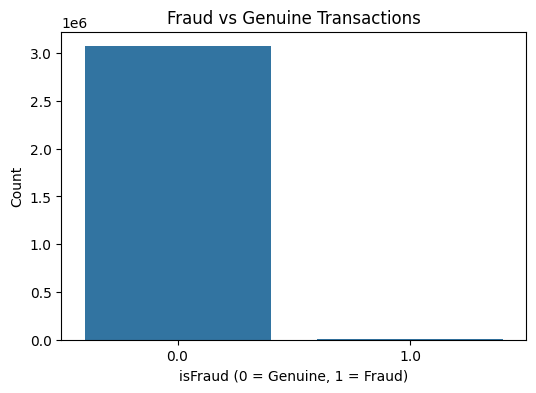

In [ ]:
# Exploratory Data Analysis using Countplot
#step 15:Fraud vs Genuine Transactions
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("isFraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

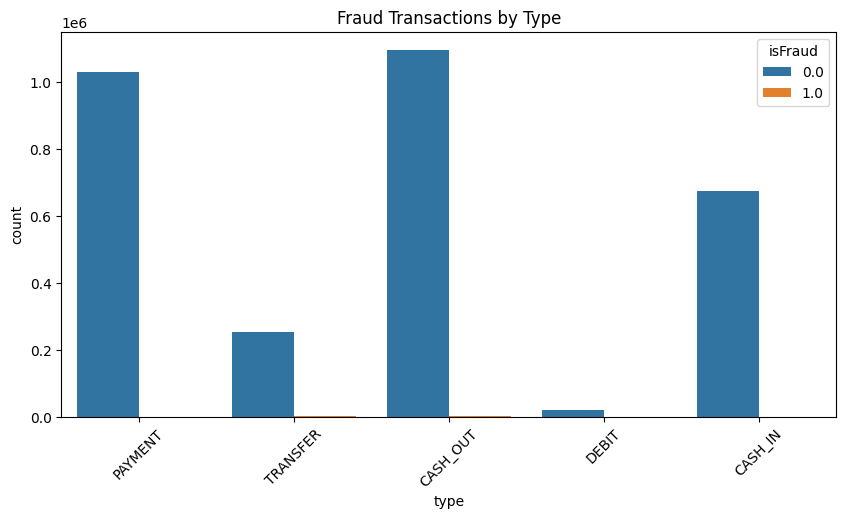

In [ ]:
#Step 16: Fraud by Transaction type using Countplot

plt.figure(figsize=(10,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud Transactions by Type")

plt.xticks(rotation=45)

plt.show()

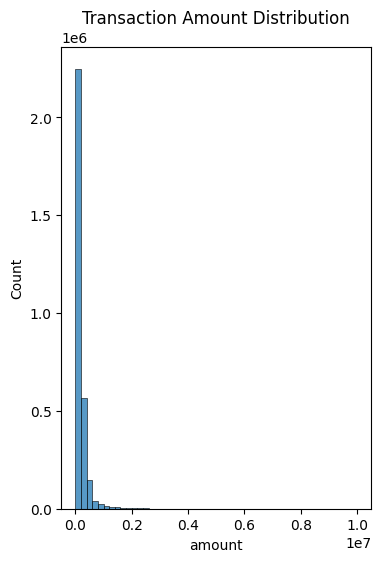

In [ ]:
#Step 17: Amount Distribution using Histogram

plt.figure(figsize=(4,6))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

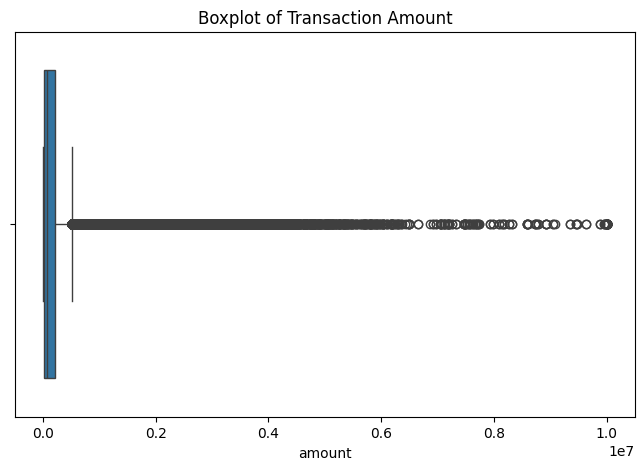

In [ ]:
# Step 18: Box Plot for Amount

plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

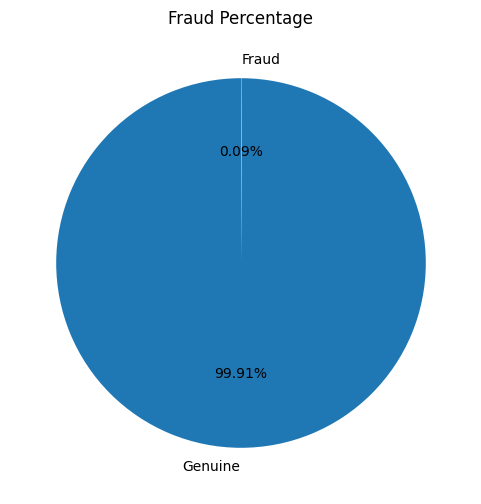

In [ ]:
#Step 19: Fraud Percentage

fraud = df["isFraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud Percentage")

plt.show()

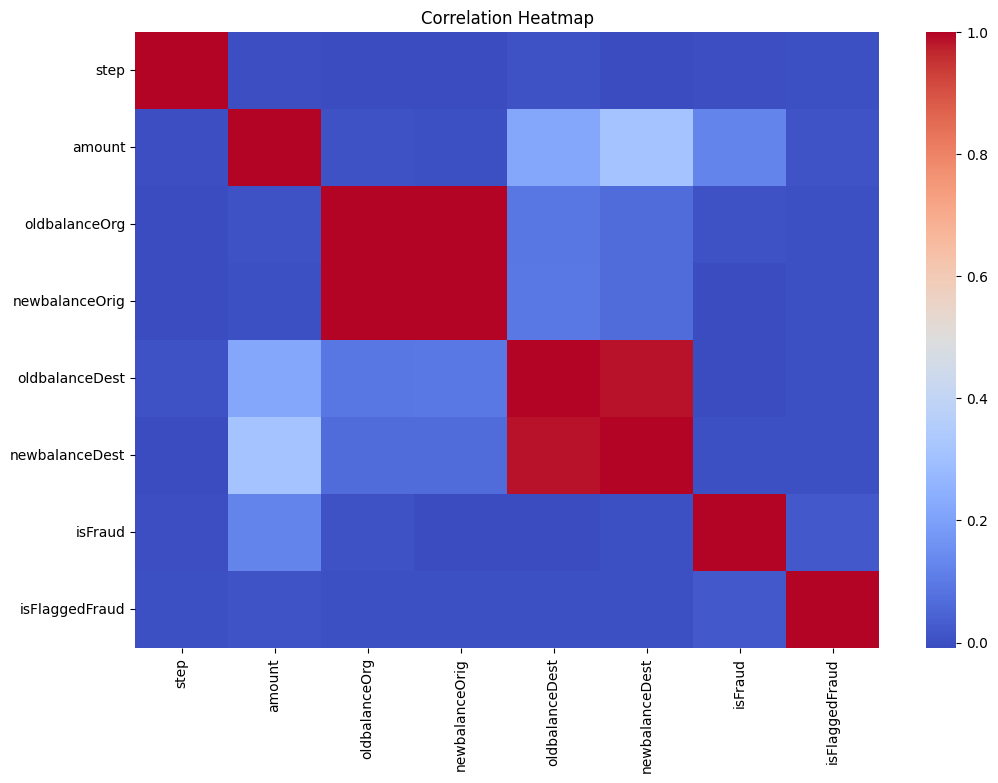

In [ ]:
# Step 20: Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

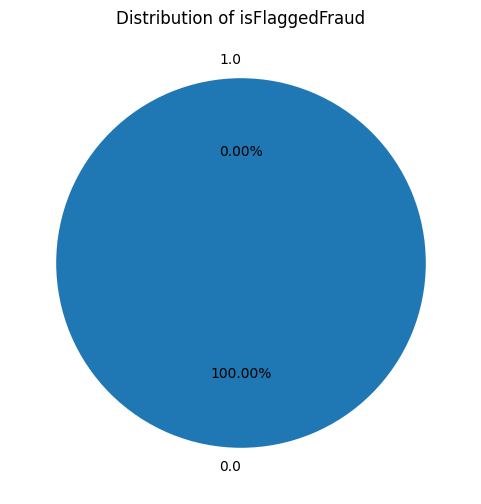

In [ ]:
# step 21: Visualize isFlaggedFraud
import matplotlib.pyplot as plt

# Value counts
flag_counts = df['isFlaggedFraud'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(flag_counts,
        labels=flag_counts.index,
        autopct='%1.2f%%',
        startangle=90)

plt.title("Distribution of isFlaggedFraud")
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
# Step 22: Check Data Types
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
dtype: object


In [ ]:
# Step 23: Label Encoding
# Convert Transaction Type into Numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

print("\nEncoded Transaction Types")
print(df["type"].unique())


Encoded Transaction Types
[3 4 1 2 0]


In [ ]:

# Step 24: Remove Unnecessary Columns

df.drop(["nameOrig", "nameDest","isFlaggedFraud"], axis=1, inplace=True)

print("\nRemaining Columns")
print(df.columns)


Remaining Columns
Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')


In [ ]:
#Step 25: Features and Target

X = df.drop("isFraud", axis=1)

y = df["isFraud"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (3074084, 7)
Target Shape: (3074084,)


In [ ]:
# Step 26: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (2459267, 7)
Testing Data Shape: (614817, 7)


In [ ]:

# Step 27: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Step 28: Check Class Distribution

print("\nClass Distribution Before SMOTE")
print(y_train.value_counts())


Class Distribution Before SMOTE
isFraud
0.0    2457146
1.0       2121
Name: count, dtype: int64


In [ ]:
# Step 29: Handle Imbalanced Data using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nClass Distribution After SMOTE")
print(y_train_smote.value_counts())

print("\nBalanced Training Data Shape")
print(X_train_smote.shape)


Class Distribution After SMOTE
isFraud
0.0    2457146
1.0    2457146
Name: count, dtype: int64

Balanced Training Data Shape
(4914292, 7)


In [ ]:
#Step 30: Import Machine Learning Models


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#Step 31: Logistic Regression


lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

print("========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy : 0.9673040921119618
Precision: 0.022913416536661468
Recall   : 0.8867924528301887
F1 Score : 0.04467255964261952

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98    614287
         1.0       0.02      0.89      0.04       530

    accuracy                           0.97    614817
   macro avg       0.51      0.93      0.51    614817
weighted avg       1.00      0.97      0.98    614817


Confusion Matrix
[[594245  20042]
 [    60    470]]


In [ ]:
#Step 32: Decision Tree


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))


========== Decision Tree ==========
Accuracy : 0.9990891598638294
Precision: 0.4849699398797595
Recall   : 0.9132075471698113
F1 Score : 0.6335078534031413

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    614287
         1.0       0.48      0.91      0.63       530

    accuracy                           1.00    614817
   macro avg       0.74      0.96      0.82    614817
weighted avg       1.00      1.00      1.00    614817


Confusion Matrix
[[613773    514]
 [    46    484]]


In [ ]:
# Step 33: Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))


========== Random Forest ==========
Accuracy : 0.9993851829080849
Precision: 0.5974358974358974
Recall   : 0.879245283018868
F1 Score : 0.7114503816793893

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    614287
         1.0       0.60      0.88      0.71       530

    accuracy                           1.00    614817
   macro avg       0.80      0.94      0.86    614817
weighted avg       1.00      1.00      1.00    614817


Confusion Matrix
[[613973    314]
 [    64    466]]


In [ ]:
#step34: Results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

print("\nBest Model Based on Accuracy")
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.967304   0.022913  0.886792  0.044673
1        Decision Tree  0.999089   0.484970  0.913208  0.633508
2        Random Forest  0.999385   0.597436  0.879245  0.711450

Best Model Based on Accuracy
                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.999385   0.597436  0.879245  0.711450
1        Decision Tree  0.999089   0.484970  0.913208  0.633508
0  Logistic Regression  0.967304   0.022913  0.886792  0.044673


In [ ]:
#Final Results
#Model             Accuracy
#Logistic Regression 96%
#Decision Tree.      99%
#Random Forest.      99%